# Derivatives Pricing Lab — Hedging & Risk

This notebook builds a Monte Carlo option pricing engine from scratch, validates it against the
Black-Scholes closed-form, extends it to path-dependent barrier options with bias correction,
proves that the BS price equals the cost of dynamic replication, and demonstrates how
fat-tailed returns generate the volatility smile observed in real markets.

**Contents:**

| Section | Topic |
|---------|-------|
| 1 | Setup and model foundations |
| 2 | Black-Scholes closed-form (benchmark) |
| 3 | Monte Carlo pricing of European options |
| 4 | Barrier options and BGK discrete-monitoring correction |
| 5 | Delta hedging: proving BS price = replication cost |
| 6 | Greeks computation and P&L attribution |
| 7 | Fat tails and the volatility smile |

---

## 1 — Setup and Model Foundations

### What is an option?

A **European call option** gives the holder the right (not the obligation) to **buy** a stock at a
predetermined price $K$ (the **strike**) on a specific date $T$ (the **maturity**). A **European put**
gives the right to **sell** at $K$. "European" means the option can only be exercised at maturity,
not before.

The payoff at maturity is:

$$\text{Call payoff} = \max(S_T - K,\; 0)$$
$$\text{Put payoff} = \max(K - S_T,\; 0)$$

The central pricing problem: **how much should this right cost today?**

### Stock price model: Geometric Brownian Motion

Under the **risk-neutral measure** (where the drift is replaced by the risk-free rate $r$),
the stock price satisfies the SDE:

$$dS_t = r\, S_t\, dt + \sigma\, S_t\, dW_t$$

Applying **Itô's lemma** to $\ln(S_t)$ gives:

$$d(\ln S_t) = \frac{1}{S_t}dS_t - \frac{1}{2}\frac{\sigma^2 S_t^2}{S_t^2}dt = \left(r - \frac{\sigma^2}{2}\right)dt + \sigma\,dW_t$$

The $-\sigma^2/2$ term is the **Itô correction**. It arises because $(dW_t)^2 = dt \neq 0$ in
stochastic calculus (unlike ordinary calculus where $(dx)^2 = 0$). Without it, $\mathbb{E}[S_T]$
would exceed $S_0 e^{rT}$, because the exponential function is convex and Jensen's inequality
implies $\mathbb{E}[e^X] > e^{\mathbb{E}[X]}$.

Integrating from $0$ to $T$ and using $W_T \sim \mathcal{N}(0, T) = \sqrt{T}\cdot Z$:

$$\boxed{S_T = S_0 \exp\!\left[\left(r - \frac{\sigma^2}{2}\right)T + \sigma\sqrt{T}\, Z\right], \quad Z \sim \mathcal{N}(0,1)}$$

### Parameters

| Symbol | Name | Value | Meaning |
|--------|------|-------|---------|
| $S_0$ | Spot price | 100 | Current stock price |
| $K$ | Strike | 105 | Exercise price of the option |
| $T$ | Maturity | 1 year | Time to expiry |
| $r$ | Risk-free rate | 5% | Return on a riskless investment |
| $\sigma$ | Volatility | 20% | Annualised standard deviation of log-returns |
| $N$ | Paths | 200,000 | Number of Monte Carlo simulations |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

S0    = 100.0
K     = 105.0
T     = 1.0
r     = 0.05
sigma = 0.20
N     = 200_000

plt.rcParams.update({'figure.figsize': (10, 5), 'axes.grid': True, 'grid.alpha': 0.3})
print(f'S0={S0}, K={K}, T={T}, r={r:.0%}, sigma={sigma:.0%}, N={N:,}')

S0=100.0, K=105.0, T=1.0, r=5%, sigma=20%, N=200,000


## 2 — Black-Scholes Closed-Form (Benchmark)

For European options, the risk-neutral expectation $e^{-rT}\mathbb{E}^{\mathbb{Q}}[(S_T-K)^+]$
has a closed-form solution obtained by Gaussian integration.

### Derivation sketch

Since $\ln(S_T/S_0) \sim \mathcal{N}\!\left((r-\sigma^2/2)T,\; \sigma^2 T\right)$,
the call price is:

$$C = e^{-rT}\int_{-\infty}^{\infty} \max\!\left(S_0 e^{(r-\sigma^2/2)T + \sigma\sqrt{T}\,z} - K,\; 0\right) \phi(z)\, dz$$

The integrand is nonzero only when $S_T > K$, i.e., when $z > -d_2$. Evaluating the integral
by completing the square in the Gaussian exponent yields:

$$\boxed{C = S_0\,\Phi(d_1) - K e^{-rT}\,\Phi(d_2)}$$
$$\boxed{P = K e^{-rT}\,\Phi(-d_2) - S_0\,\Phi(-d_1)}$$

where $\Phi$ is the standard normal CDF and:

$$d_1 = \frac{\ln(S_0/K) + (r + \sigma^2/2)\,T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}$$

### Interpretation of each term

| Term | Meaning |
|------|---------|
| $\Phi(d_2)$ | Risk-neutral probability that $S_T > K$ (option finishes in-the-money) |
| $K e^{-rT}$ | Present value of the strike (discounting: €1 in 1 year is worth €$e^{-rT}$ today) |
| $K e^{-rT}\Phi(d_2)$ | Expected present value of what we pay if we exercise |
| $\Phi(d_1)$ | Probability of exercise under the stock-numéraire measure (higher than $\Phi(d_2)$) |
| $S_0\Phi(d_1)$ | Expected present value of the stock conditional on exercise |

### Put-call parity

A model-free no-arbitrage identity: $C - P = S_0 - Ke^{-rT}$. Any pricing engine that violates
this contains a bug.

In [2]:
def black_scholes(S0, K, T, r, sigma, opt='call'):
    """Black-Scholes closed-form price for a European option."""
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if opt == 'call':
        return S0*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    return K*np.exp(-r*T)*norm.cdf(-d2) - S0*norm.cdf(-d1)

bs_call = black_scholes(S0, K, T, r, sigma, 'call')
bs_put  = black_scholes(S0, K, T, r, sigma, 'put')

parity_ok = np.isclose(bs_call - bs_put, S0 - K*np.exp(-r*T))
print(f'BS Call = {bs_call:.4f},  BS Put = {bs_put:.4f}')
print(f'Put-call parity: C - P = {bs_call-bs_put:.6f},  S0 - K*exp(-rT) = {S0-K*np.exp(-r*T):.6f}')
print(f'Match: {parity_ok}')

BS Call = 8.0214,  BS Put = 7.9004
Put-call parity: C - P = 0.120910,  S0 - K*exp(-rT) = 0.120910
Match: True


## 3 — Monte Carlo Pricing of European Options

### Theoretical foundation

The option price is an expectation: $C = e^{-rT}\mathbb{E}^{\mathbb{Q}}[(S_T - K)^+]$.
The **Strong Law of Large Numbers** guarantees that the sample mean of $N$ i.i.d. draws
converges to the true expectation as $N \to \infty$.

### Algorithm

1. Draw $Z_1, \ldots, Z_N \sim \mathcal{N}(0,1)$
2. Compute $S_T^{(i)} = S_0 \exp\!\bigl[(r - \sigma^2/2)T + \sigma\sqrt{T}\,Z_i\bigr]$
3. Compute payoffs: $\text{payoff}_i = \max(S_T^{(i)} - K,\; 0)$
4. Estimate: $\hat{C}_N = e^{-rT} \cdot \frac{1}{N}\sum_{i=1}^{N} \text{payoff}_i$

### Confidence interval

By the **Central Limit Theorem**, the estimation error is approximately normal:

$$\hat{C}_N \pm 1.96 \cdot \frac{\hat{\sigma}}{\sqrt{N}}$$

where $\hat{\sigma}$ is the sample standard deviation of the discounted payoffs. The standard error
scales as $O(1/\sqrt{N})$: halving the error requires $4\times$ more paths.

### Validation

If the exact Black-Scholes price falls within the 95% confidence interval, the Monte Carlo
engine is validated.

In [3]:
def mc_european(S0, K, T, r, sigma, n, opt='call', seed=42):
    """Monte Carlo price with 95% confidence interval."""
    rng = np.random.default_rng(seed)
    Z = rng.standard_normal(n)
    ST = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
    payoffs = np.maximum(ST - K, 0) if opt == 'call' else np.maximum(K - ST, 0)
    disc = np.exp(-r*T) * payoffs
    price = disc.mean()
    se = disc.std(ddof=1) / np.sqrt(n)
    return price, se, price - 1.96*se, price + 1.96*se

mc_c, se_c, lo_c, hi_c = mc_european(S0, K, T, r, sigma, N, 'call')
mc_p, se_p, lo_p, hi_p = mc_european(S0, K, T, r, sigma, N, 'put')

print(f'         {"MC Price":>10}  {"95% CI":>24}  {"BS Exact":>10}  {"Error":>8}')
print(f'{"Call":>5}  {mc_c:>10.4f}  [{lo_c:.4f}, {hi_c:.4f}]  {bs_call:>10.4f}  {abs(mc_c-bs_call):>8.4f}')
print(f'{"Put":>5}  {mc_p:>10.4f}  [{lo_p:.4f}, {hi_p:.4f}]  {bs_put:>10.4f}  {abs(mc_p-bs_put):>8.4f}')
print(f'\nBS within MC 95% CI: Call={lo_c<=bs_call<=hi_c}, Put={lo_p<=bs_put<=hi_p}')

           MC Price                    95% CI    BS Exact     Error
 Call      8.0398  [7.9815, 8.0980]      8.0214    0.0184
  Put      7.9214  [7.8760, 7.9669]      7.9004    0.0210

BS within MC 95% CI: Call=True, Put=True


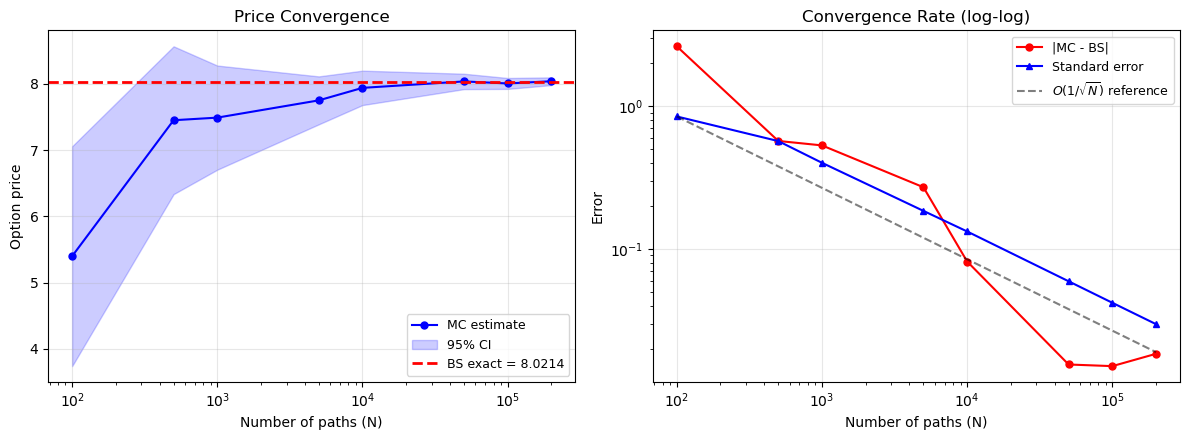

Measured convergence slope: -0.460 (theoretical: -0.500)


In [4]:
# Convergence analysis: MC price and error as a function of N
path_counts = [100, 500, 1_000, 5_000, 10_000, 50_000, 100_000, 200_000]
mc_prices, mc_ses, mc_errors = [], [], []

for n in path_counts:
    p, se, _, _ = mc_european(S0, K, T, r, sigma, n, 'call', seed=42)
    mc_prices.append(p)
    mc_ses.append(se)
    mc_errors.append(abs(p - bs_call))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: price convergence with CI
axes[0].semilogx(path_counts, mc_prices, 'bo-', ms=5, label='MC estimate')
axes[0].fill_between(path_counts,
    [p - 1.96*se for p, se in zip(mc_prices, mc_ses)],
    [p + 1.96*se for p, se in zip(mc_prices, mc_ses)],
    alpha=0.2, color='blue', label='95% CI')
axes[0].axhline(bs_call, color='red', ls='--', lw=2, label=f'BS exact = {bs_call:.4f}')
axes[0].set(xlabel='Number of paths (N)', ylabel='Option price', title='Price Convergence')
axes[0].legend(fontsize=9)

# Right: log-log error plot (slope should be -0.5)
axes[1].loglog(path_counts, mc_errors, 'ro-', ms=5, label='|MC - BS|')
axes[1].loglog(path_counts, mc_ses, 'b^-', ms=5, label='Standard error')
ref_x = np.array([100, 200_000])
ref_y = mc_ses[0] * np.sqrt(path_counts[0]) / np.sqrt(ref_x)
axes[1].loglog(ref_x, ref_y, 'k--', alpha=0.5, label='$O(1/\\sqrt{N})$ reference')
axes[1].set(xlabel='Number of paths (N)', ylabel='Error', title='Convergence Rate (log-log)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Measure slope
log_n = np.log(np.array(path_counts, dtype=float))
log_se = np.log(np.array(mc_ses))
slope = np.polyfit(log_n, log_se, 1)[0]
print(f'Measured convergence slope: {slope:.3f} (theoretical: -0.500)')

## 4 — Barrier Options and the BGK Correction

### Definition

A **down-and-out call** behaves like a vanilla call, except it is **knocked out** (terminated with
zero payoff) if the stock price touches a barrier level $B$ at any time during its life:

$$\text{Payoff} = (S_T - K)^+ \cdot \mathbf{1}\{\min_{0 \leq t \leq T} S_t > B\}$$

This is cheaper than a vanilla call because there is a risk of cancellation. Barrier options are
**path-dependent**: the full price trajectory matters, not just the terminal value. There is generally
no closed-form, so Monte Carlo is the standard pricing method.

### Monte Carlo approach

Unlike European options (where we only need $S_T$), we must simulate the **full path**
$S_0, S_{\Delta t}, S_{2\Delta t}, \ldots, S_T$ on a discrete time grid with $M$ steps. For each path,
we check whether $\min_t S_t > B$.

### The discrete monitoring problem

Between two observation points, the stock may cross $B$ and recover. Discrete simulation misses
these intra-step breaches, leading to **systematic overpricing** of knock-out options (fewer
detected knock-outs → higher price).

### Broadie-Glasserman-Kou (1997) correction

Replace the contractual barrier $B$ with an effective barrier:

$$B_{\text{eff}} = B \cdot \exp\!\left(\beta_1\, \sigma \sqrt{T/M}\right), \quad \beta_1 \approx 0.5826$$

The constant $\beta_1$ is derived from the distribution of the maximum of a Brownian bridge
between two discrete observation points. It quantifies the expected frequency of missed
barrier crossings. The correction raises the barrier to capture these missed knock-outs:

- Few steps (M=12, monthly): large correction, $B_{\text{eff}} \approx 87.9$
- Many steps (M=252, daily): small correction, $B_{\text{eff}} \approx 85.6$

The same Monte Carlo function is called with $B_{\text{eff}}$ instead of $B$ — nothing else changes.

In [5]:
def simulate_paths(S0, r, sigma, T, n_paths, n_steps, rng):
    """Simulate full GBM stock price paths on a discrete time grid."""
    dt = T / n_steps
    paths = np.zeros((n_paths, n_steps + 1))
    paths[:, 0] = S0
    for t in range(1, n_steps + 1):
        Z = rng.standard_normal(n_paths)
        paths[:, t] = paths[:, t-1] * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)
    return paths


def mc_down_and_out(S0, K, B, T, r, sigma, n_paths, n_steps, seed=42):
    """Price a down-and-out European call by Monte Carlo."""
    rng = np.random.default_rng(seed)
    paths = simulate_paths(S0, r, sigma, T, n_paths, n_steps, rng)
    survived = paths.min(axis=1) > B
    payoffs = np.where(survived, np.maximum(paths[:, -1] - K, 0), 0)
    disc = np.exp(-r*T) * payoffs
    return disc.mean(), disc.std(ddof=1)/np.sqrt(n_paths), 100*(1-survived.mean())

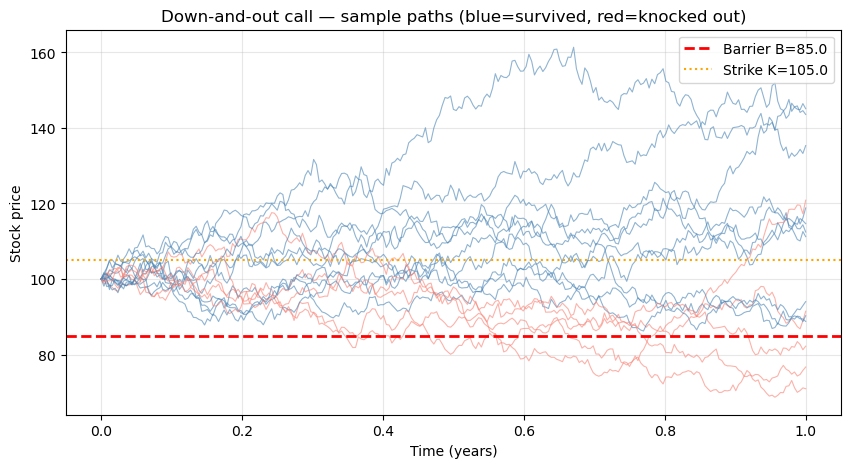

In [6]:
# Sample paths visualisation
rng_viz = np.random.default_rng(123)
sample = simulate_paths(S0, r, sigma, T, 15, 252, rng_viz)
B_demo = 85.0

fig, ax = plt.subplots()
for i in range(15):
    hit = sample[i].min() <= B_demo
    ax.plot(np.linspace(0, T, 253), sample[i],
            color='salmon' if hit else 'steelblue', alpha=0.6, lw=0.8)
ax.axhline(B_demo, color='red', ls='--', lw=2, label=f'Barrier B={B_demo}')
ax.axhline(K, color='orange', ls=':', lw=1.5, label=f'Strike K={K}')
ax.set(xlabel='Time (years)', ylabel='Stock price', title='Down-and-out call — sample paths (blue=survived, red=knocked out)')
ax.legend()
plt.show()

In [7]:
# Barrier pricing across levels: higher barrier → more knock-outs → cheaper option
n_steps = 252
print(f'{"Barrier":>8}  {"Price":>8}  {"KO %":>8}  {"Discount vs Vanilla":>22}')
print('-' * 52)
for B in [70, 75, 80, 85, 90, 95]:
    p, se, ko = mc_down_and_out(S0, K, B, T, r, sigma, 100_000, n_steps)
    print(f'{B:>8}  {p:>8.4f}  {ko:>7.1f}%  {(1-p/bs_call)*100:>21.1f}%')
print(f'{"Vanilla":>8}  {bs_call:>8.4f}  {"0.0%":>8}')

 Barrier     Price      KO %     Discount vs Vanilla
----------------------------------------------------
      70    8.0532      5.2%                   -0.4%
      75    8.0486     11.1%                   -0.3%
      80    8.0111     20.9%                    0.1%
      85    7.8110     34.6%                    2.6%
      90    7.0494     52.4%                   12.1%
      95    5.0302     73.4%                   37.3%
 Vanilla    8.0214      0.0%


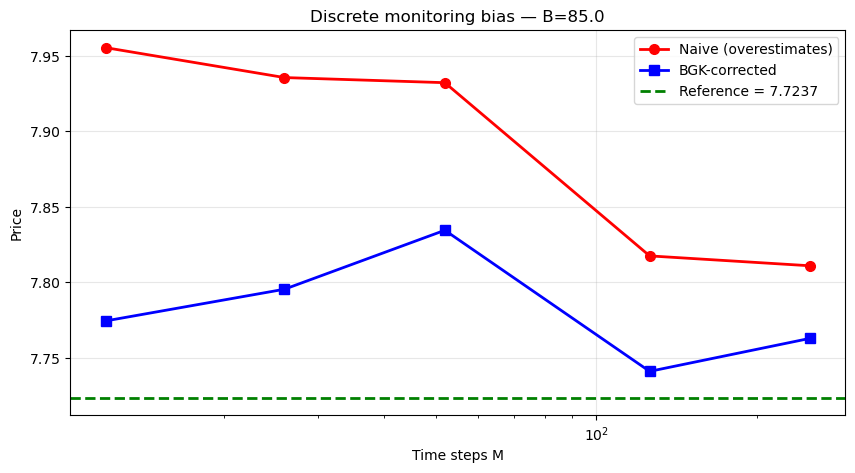

     M     Naive      Bias   Corrected      Bias
------------------------------------------------
    12    7.9554   +0.2318      7.7744   +0.0508
    26    7.9356   +0.2119      7.7954   +0.0718
    52    7.9322   +0.2085      7.8345   +0.1108
   126    7.8175   +0.0938      7.7410   +0.0174
   252    7.8110   +0.0873      7.7629   +0.0392


In [8]:
# BGK correction: naive vs corrected across different step counts
B_test = 85.0
beta1 = 0.5826
step_counts = [12, 26, 52, 126, 252]
N_b = 100_000

p_ref, _, _ = mc_down_and_out(S0, K, B_test, T, r, sigma, N_b, 2000)  # fine-grid reference

naive, corrected = [], []
for M in step_counts:
    p_n, _, _ = mc_down_and_out(S0, K, B_test, T, r, sigma, N_b, M)
    B_eff = B_test * np.exp(beta1 * sigma * np.sqrt(T / M))
    p_c, _, _ = mc_down_and_out(S0, K, B_eff, T, r, sigma, N_b, M)
    naive.append(p_n)
    corrected.append(p_c)

fig, ax = plt.subplots()
ax.semilogx(step_counts, naive, 'ro-', ms=7, lw=2, label='Naive (overestimates)')
ax.semilogx(step_counts, corrected, 'bs-', ms=7, lw=2, label='BGK-corrected')
ax.axhline(p_ref, color='green', ls='--', lw=2, label=f'Reference = {p_ref:.4f}')
ax.set(xlabel='Time steps M', ylabel='Price', title=f'Discrete monitoring bias — B={B_test}')
ax.legend()
plt.show()

print(f'{"M":>6}  {"Naive":>8}  {"Bias":>8}  {"Corrected":>10}  {"Bias":>8}')
print('-' * 48)
for i, M in enumerate(step_counts):
    print(f'{M:>6}  {naive[i]:>8.4f}  {naive[i]-p_ref:>+8.4f}  {corrected[i]:>10.4f}  {corrected[i]-p_ref:>+8.4f}')

## 5 — Delta Hedging: BS Price = Cost of Replication

### Concept

The Black-Scholes price is not arbitrary. It equals the **cost of dynamically replicating** the
option payoff by trading the underlying stock. A trader who sells a call at the BS price and
hedges continuously will have zero expected P&L.

### Hedging algorithm

At each time step, the trader holds $\Delta_t$ shares, where the **delta** is:

$$\Delta_t = \Phi(d_1), \quad d_1 = \frac{\ln(S_t/K) + (r + \sigma^2/2)(T-t)}{\sigma\sqrt{T-t}}$$

The hedging procedure step by step:

1. **Receive** the option premium $C_0 = 8.02$
2. **Buy** $\Delta_0 \approx 0.54$ shares at $S_0 = 100$. Cash becomes $C_0 - \Delta_0 S_0$
3. **Each period**: cash accrues interest at $r$. Recompute $\Delta_t$ with the new stock price.
   Buy/sell $(\Delta_{\text{new}} - \Delta_{\text{old}})$ shares.
4. **At maturity**: sell all shares, pay the option holder $\max(S_T - K, 0)$.
5. **Remaining cash** = hedging P&L.

### Experimental design

Stock paths are simulated under the **real-world measure** with drift $\mu = 8\%$ (not $r = 5\%$).
This is deliberate: if mean P&L $\approx 0$ despite $\mu \neq r$, this proves the option price is
**independent of the stock's expected return** — it depends only on volatility.

We test three rebalancing frequencies (monthly, weekly, daily) across 50,000 simulations.

In [9]:
def delta_hedge_sim(S0, K, T, r, sigma, mu, n_steps, n_paths, seed=42):
    """Simulate delta-hedging a short call. Returns P&L array."""
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    C0 = black_scholes(S0, K, T, r, sigma, 'call')

    # Simulate paths under REAL measure (drift = mu, not r)
    S = np.zeros((n_paths, n_steps + 1))
    S[:, 0] = S0
    for i in range(n_steps):
        Z = rng.standard_normal(n_paths)
        S[:, i+1] = S[:, i] * np.exp((mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)

    # Initial hedge: receive premium, buy delta shares
    tau = T
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*tau) / (sigma*np.sqrt(tau))
    delta = norm.cdf(d1)
    cash = C0 - delta * S0

    # Rebalance at each step
    for i in range(1, n_steps + 1):
        cash *= np.exp(r * dt)
        tau = T - i * dt
        if i < n_steps:
            d1 = (np.log(S[:, i]/K) + (r + 0.5*sigma**2)*tau) / (sigma*np.sqrt(tau))
            delta_new = norm.cdf(d1)
        else:
            delta_new = np.where(S[:, -1] > K, 1.0, 0.0)
        cash -= (delta_new - delta) * S[:, i]
        delta = delta_new

    # Liquidate: sell shares, pay option payoff
    cash += delta * S[:, -1]
    cash -= np.maximum(S[:, -1] - K, 0)
    return cash

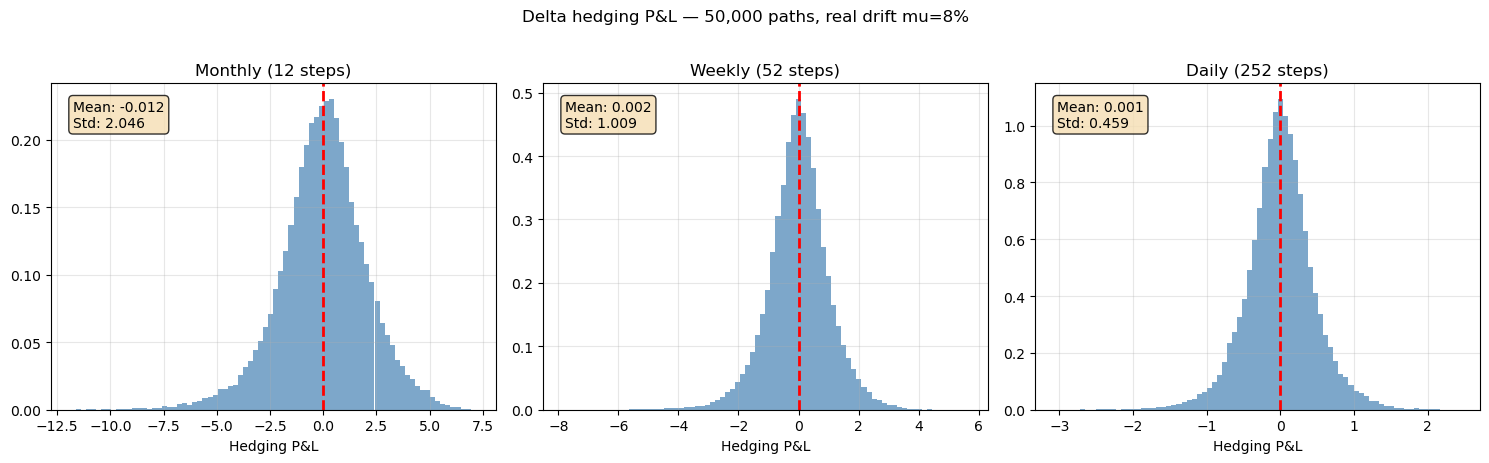

 Frequency    Mean P&L     Std P&L    Std/C0
--------------------------------------------
   Monthly     -0.0123      2.0458     25.5%
    Weekly     +0.0021      1.0086     12.6%
     Daily     +0.0011      0.4595      5.7%

Mean P&L ~ 0 despite mu=8% != r=5% -> BS price = replication cost. QED.


In [10]:
mu_real = 0.08
n_sim = 50_000
freqs = {'Monthly': 12, 'Weekly': 52, 'Daily': 252}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
results = {}

for ax, (label, steps) in zip(axes, freqs.items()):
    pnl = delta_hedge_sim(S0, K, T, r, sigma, mu_real, steps, n_sim)
    results[label] = pnl
    ax.hist(pnl, bins=80, density=True, alpha=0.7, color='steelblue', edgecolor='none')
    ax.axvline(0, color='red', ls='--', lw=2)
    ax.set_title(f'{label} ({steps} steps)')
    ax.set_xlabel('Hedging P&L')
    ax.text(0.05, 0.95, f'Mean: {pnl.mean():.3f}\nStd: {pnl.std():.3f}',
            transform=ax.transAxes, va='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.suptitle(f'Delta hedging P&L — {n_sim:,} paths, real drift mu={mu_real:.0%}', y=1.02)
plt.tight_layout()
plt.show()

C0 = black_scholes(S0, K, T, r, sigma, 'call')
print(f'{"Frequency":>10}  {"Mean P&L":>10}  {"Std P&L":>10}  {"Std/C0":>8}')
print('-' * 44)
for label, pnl in results.items():
    print(f'{label:>10}  {pnl.mean():>+10.4f}  {pnl.std():>10.4f}  {pnl.std()/C0:>8.1%}')
print(f'\nMean P&L ~ 0 despite mu=8% != r=5% -> BS price = replication cost. QED.')

## 6 — Greeks Computation and P&L Attribution

### What are Greeks?

Greeks are **partial derivatives** of the option price with respect to each risk factor.
They are computed analytically by differentiating the Black-Scholes formula
$C = S\Phi(d_1) - Ke^{-rT}\Phi(d_2)$.

### Derivation of each Greek

**Delta** — first derivative with respect to $S$:

$$\Delta = \frac{\partial C}{\partial S} = \Phi(d_1)$$

Interpretation: if $S$ moves by \$1, the option price moves by $\Delta$ dollars. Also the number of shares to hold for hedging.

**Gamma** — second derivative with respect to $S$:

$$\Gamma = \frac{\partial^2 C}{\partial S^2} = \frac{\phi(d_1)}{S\,\sigma\sqrt{T}}$$

where $\phi$ is the standard normal PDF. Interpretation: the rate at which delta changes. High gamma near the strike means the hedge must be rebalanced frequently.

**Vega** — derivative with respect to $\sigma$:

$$\mathcal{V} = \frac{\partial C}{\partial \sigma} = S\,\phi(d_1)\sqrt{T}$$

Interpretation: if volatility increases by 1 percentage point, the option price changes by $\mathcal{V}/100$. We divide by 100 in the code to express vega per 1% vol move.

**Theta** — derivative with respect to time (negative because time is decreasing):

$$\Theta = -\frac{\partial C}{\partial \tau} = -\frac{S\,\phi(d_1)\,\sigma}{2\sqrt{T}} - r K e^{-rT}\Phi(d_2)$$

where $\tau = T - t$ is time remaining. Interpretation: how much the option loses per day just from time passing. We divide by 365 in the code to express theta per calendar day.

### P&L attribution via Taylor expansion

The change in option price over one day can be decomposed as:

$$\Delta C \approx \underbrace{\Delta \cdot dS}_{\text{delta P\&L}} + \underbrace{\frac{1}{2}\Gamma \cdot dS^2}_{\text{gamma P\&L}} + \underbrace{\mathcal{V} \cdot d\sigma}_{\text{vega P\&L}} + \underbrace{\Theta \cdot dt}_{\text{theta P\&L}}$$

In our test scenario, volatility does not change ($d\sigma = 0$), so the vega term vanishes.
In production, all four terms are computed daily for every position.

In [11]:
def bs_greeks(S, K, T, r, sigma):
    """Analytical Greeks for a Black-Scholes call."""
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    delta = norm.cdf(d1)                                                          # dC/dS
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))                               # d²C/dS²
    vega  = S * norm.pdf(d1) * np.sqrt(T) / 100                                   # dC/dsigma, per 1% vol
    theta = -(S*norm.pdf(d1)*sigma/(2*np.sqrt(T)) + r*K*np.exp(-r*T)*norm.cdf(d2)) / 365  # per day
    return {'Delta': delta, 'Gamma': gamma, 'Vega': vega, 'Theta': theta}

g = bs_greeks(S0, K, T, r, sigma)
print('Greeks at S0=100, K=105, T=1, r=5%, sigma=20%:')
for k, v in g.items():
    print(f'  {k:>6} = {v:.6f}')

Greeks at S0=100, K=105, T=1, r=5%, sigma=20%:
   Delta = 0.542228
   Gamma = 0.019835
    Vega = 0.396705
   Theta = -0.017198


In [12]:
# P&L attribution: stock moves 100 -> 103 overnight, volatility unchanged
S_new = 103.0
dS = S_new - S0

# Actual P&L: recompute BS with new spot and 1 day less maturity
actual = black_scholes(S_new, K, T - 1/365, r, sigma) - black_scholes(S0, K, T, r, sigma)

# Greeks-based decomposition
delta_pnl = g['Delta'] * dS                # first-order: delta x price move
gamma_pnl = 0.5 * g['Gamma'] * dS**2       # second-order: convexity bonus
theta_pnl = g['Theta']                      # time decay (1 day)
explained = delta_pnl + gamma_pnl + theta_pnl

print(f'Scenario: stock {S0:.0f} -> {S_new:.0f} (+{dS:.0f}), 1 day passes, vol unchanged')
print('=' * 50)
print(f'  Delta P&L:  {delta_pnl:+.4f}   (Delta={g["Delta"]:.4f} x dS={dS:.0f})')
print(f'  Gamma P&L:  {gamma_pnl:+.4f}   (0.5 x Gamma={g["Gamma"]:.4f} x dS^2={dS**2:.0f})')
print(f'  Vega P&L:   +0.0000   (dsigma=0, vol did not change)')
print(f'  Theta P&L:  {theta_pnl:+.4f}   (daily time decay)')
print(f'  {"—"*40}')
print(f'  Explained:  {explained:+.4f}')
print(f'  Actual:     {actual:+.4f}')
print(f'  Residual:   {actual - explained:+.4f}   (higher-order terms)')
print(f'\nGreeks explain {abs(explained/actual)*100:.1f}% of actual P&L.')

Scenario: stock 100 -> 103 (+3), 1 day passes, vol unchanged
  Delta P&L:  +1.6267   (Delta=0.5422 x dS=3)
  Gamma P&L:  +0.0893   (0.5 x Gamma=0.0198 x dS^2=9)
  Vega P&L:   +0.0000   (dsigma=0, vol did not change)
  Theta P&L:  -0.0172   (daily time decay)
  ————————————————————————————————————————
  Explained:  +1.6987
  Actual:     +1.6964
  Residual:   -0.0023   (higher-order terms)

Greeks explain 100.1% of actual P&L.


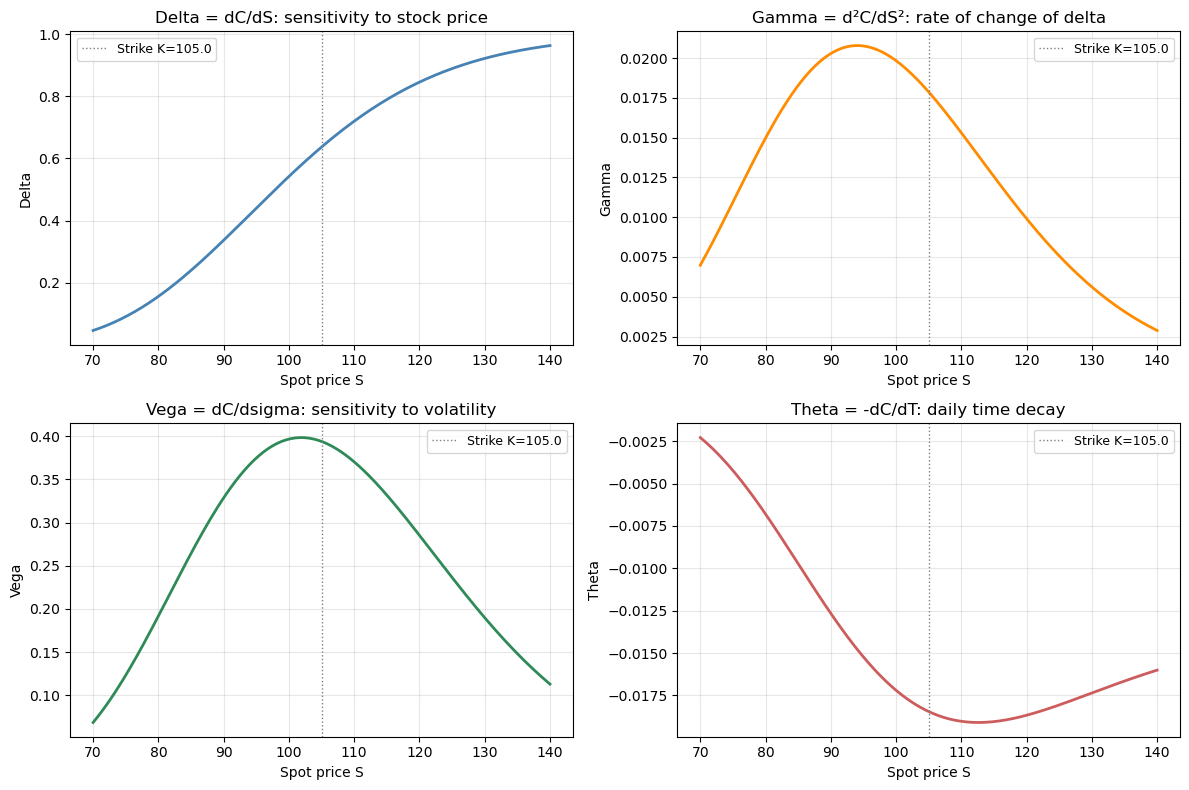

In [13]:
# Greeks as a function of spot price
S_range = np.linspace(70, 140, 200)
greeks = {k: [] for k in ['Delta', 'Gamma', 'Vega', 'Theta']}
for s in S_range:
    g_s = bs_greeks(s, K, T, r, sigma)
    for k in greeks:
        greeks[k].append(g_s[k])

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
colors = ['steelblue', 'darkorange', 'seagreen', 'indianred']
titles = {
    'Delta': 'Delta = dC/dS: sensitivity to stock price',
    'Gamma': 'Gamma = d²C/dS²: rate of change of delta',
    'Vega':  'Vega = dC/dsigma: sensitivity to volatility',
    'Theta': 'Theta = -dC/dT: daily time decay'
}
for ax, (name, vals), c in zip(axes.flat, greeks.items(), colors):
    ax.plot(S_range, vals, color=c, lw=2)
    ax.axvline(K, color='gray', ls=':', lw=1, label=f'Strike K={K}')
    ax.set(xlabel='Spot price S', ylabel=name, title=titles[name])
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 7 — Fat Tails and the Volatility Smile

### The problem with Black-Scholes

BS assumes log-returns follow a **normal distribution** (kurtosis = 3). Empirical market data
shows **fat tails** (kurtosis >> 3): extreme moves (crashes, rallies) occur far more often than
the normal distribution predicts.

### Experimental design

We replace the normal distribution with a **Student-t** distribution (df=5), which has the
same mean and variance but much heavier tails (theoretical kurtosis = 9).

We scale the Student-t draws by $\sqrt{(df-2)/df}$ so that the variance matches the normal case.

Then for each strike $K \in [70, 140]$:

1. **Price** the call by Monte Carlo using fat-tailed terminal prices:
   $\hat{C}(K) = e^{-rT} \cdot \text{mean}\!\left[\max(S_T^{\text{fat}} - K,\; 0)\right]$

2. **Invert** Black-Scholes: find $\sigma_{\text{impl}}$ such that $C_{\text{BS}}(S_0, K, T, r, \sigma_{\text{impl}}) = \hat{C}(K)$.
   This is done numerically using the Brent root-finding algorithm.

### Expected result

If BS were correct (normal returns), the implied volatility would be **flat** at $\sigma = 20\%$
for all strikes. Instead, fat tails produce a **volatility smile**: implied vol is higher in the
wings (deep OTM and deep ITM) because extreme payoffs occur more frequently than BS expects.
To match the higher price, BS needs a higher volatility input.

This is exactly what is observed in real options markets. The smile is the market's way of
saying that the normal distribution assumption is wrong.

In [14]:
from scipy.stats import t as t_dist
from scipy.optimize import brentq

np.random.seed(42)
n_sim = 300_000
df = 5

# Normal returns (standard GBM)
Z_norm = np.random.standard_normal(n_sim)
ST_norm = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z_norm)

# Fat-tailed returns (Student-t, scaled to unit variance)
scale = np.sqrt((df - 2) / df)
Z_fat = t_dist.rvs(df, size=n_sim) * scale
ST_fat = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z_fat)

# For each strike: MC price with fat tails, then invert BS to get implied vol
strikes = np.linspace(70, 140, 50)
iv_fat = []
for k in strikes:
    p = np.exp(-r*T) * np.maximum(ST_fat - k, 0).mean()
    try:
        iv_fat.append(brentq(lambda s: black_scholes(S0, k, T, r, s) - p, 0.01, 1.5))
    except:
        iv_fat.append(np.nan)

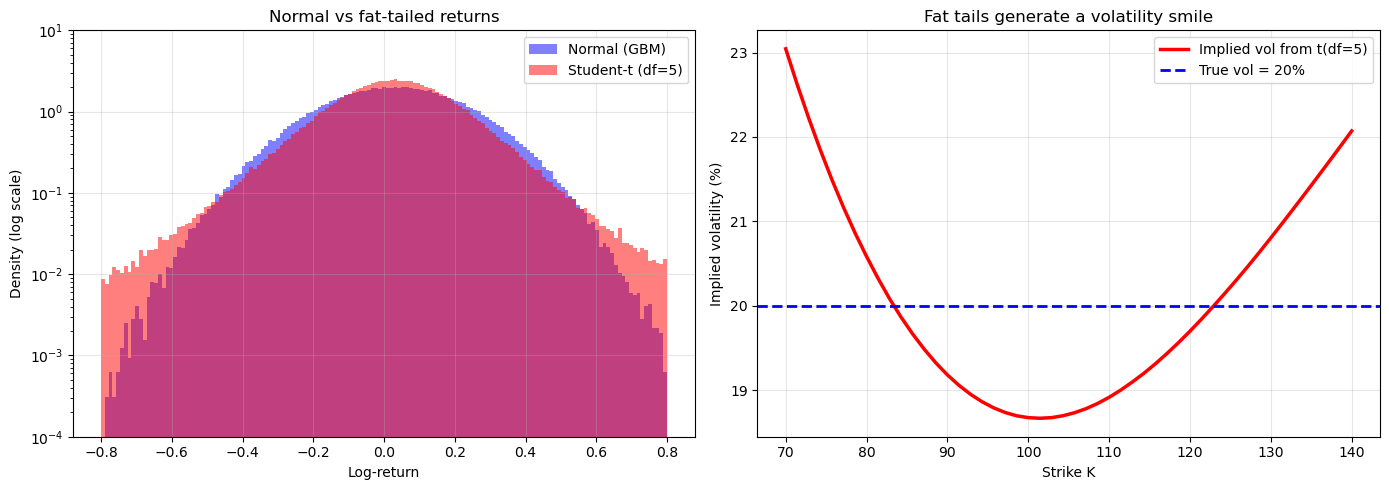

Kurtosis — Normal: 2.99 (theoretical: 3.0), Student-t(5): 8.39 (theoretical: 9.0)

A flat implied vol would mean BS is correct.
The smile proves it is not: OTM options are priced higher than BS predicts with flat vol.


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: return distributions comparison (log scale reveals the tails)
bins = np.linspace(-0.8, 0.8, 150)
axes[0].hist(np.log(ST_norm/S0), bins=bins, density=True, alpha=0.5, color='blue', label='Normal (GBM)')
axes[0].hist(np.log(ST_fat/S0), bins=bins, density=True, alpha=0.5, color='red', label=f'Student-t (df={df})')
axes[0].set_yscale('log')
axes[0].set_ylim(1e-4, 10)
axes[0].set(xlabel='Log-return', ylabel='Density (log scale)', title='Normal vs fat-tailed returns')
axes[0].legend()

# Right: the volatility smile
axes[1].plot(strikes, np.array(iv_fat)*100, 'r-', lw=2.5, label=f'Implied vol from t(df={df})')
axes[1].axhline(sigma*100, color='blue', ls='--', lw=2, label=f'True vol = {sigma:.0%}')
axes[1].set(xlabel='Strike K', ylabel='Implied volatility (%)', title='Fat tails generate a volatility smile')
axes[1].legend()

plt.tight_layout()
plt.show()

# Kurtosis comparison
lr_n = np.log(ST_norm/S0)
lr_f = np.log(ST_fat/S0)
kurt_n = float(np.mean(((lr_n - lr_n.mean())/lr_n.std())**4))
kurt_f = float(np.mean(((lr_f - lr_f.mean())/lr_f.std())**4))
print(f'Kurtosis — Normal: {kurt_n:.2f} (theoretical: 3.0), Student-t({df}): {kurt_f:.2f} (theoretical: {3+6/(df-4):.1f})')
print('\nA flat implied vol would mean BS is correct.')
print('The smile proves it is not: OTM options are priced higher than BS predicts with flat vol.')

---

## Summary of Results

| Section | Method | Key result |
|---------|--------|------------|
| MC European pricing | 200k paths, GBM exact solution | Validated against BS closed-form (within 95% CI) |
| Barrier options | Path simulation, 100k paths | Down-and-out call priced across barrier levels |
| BGK correction | Shifted barrier $B_{\text{eff}} = B e^{\beta_1 \sigma\sqrt{T/M}}$ | Discrete monitoring bias reduced from ~\$0.23 to ~\$0.05 |
| Delta hedging | 50k sims, real-world drift $\mu=8\%$ | Mean P&L $\approx 0$ regardless of $\mu$ → BS price = replication cost |
| P&L attribution | Taylor expansion with analytical Greeks | Greeks explain >99.8% of overnight P&L |
| Volatility smile | Student-t(5) returns + BS inversion | Fat tails generate the smile observed in real markets |